In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy  as np

In [2]:
I = cv2.imread('data/imagen.png')
print(I.shape)

(251, 201, 3)


In [3]:
#Irgb = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
Ib = I[:, :, 0]
Ig = I[:, :, 1]
Ir = I[:, :, 2]
Irgb = np.stack((Ir,Ig,Ib), axis=2)

(-0.5, 200.5, 250.5, -0.5)

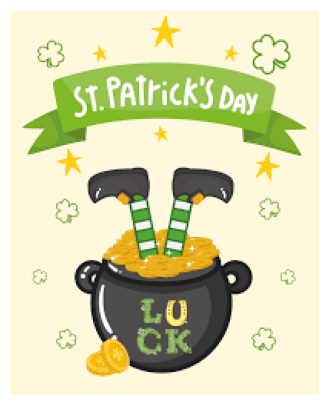

In [4]:
plt.figure(figsize=(5, 5))
plt.imshow(Irgb)
plt.axis('off')

(-0.5, 200.5, 250.5, -0.5)

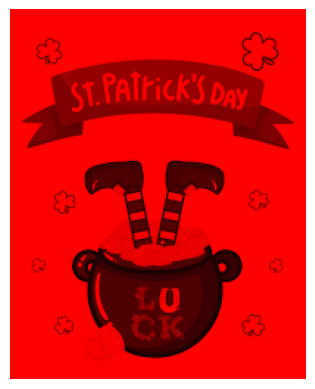

In [5]:
nr, nc, _ = Irgb.shape
Iz = np.zeros((nr,nc), dtype=np.uint8)
Ironly = np.stack((Ir,Iz,Iz),axis =2)
plt.imshow(Ironly)
plt.axis('off')

(-0.5, 200.5, 250.5, -0.5)

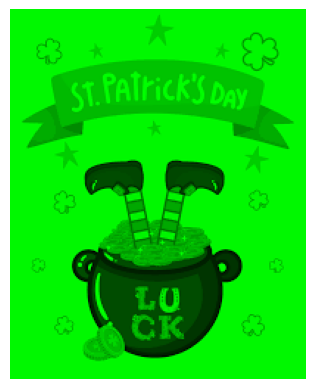

In [6]:
Igonly = np.stack((Iz,Ig,Iz),axis =2)
plt.imshow(Igonly)
plt.axis('off')

(-0.5, 200.5, 250.5, -0.5)

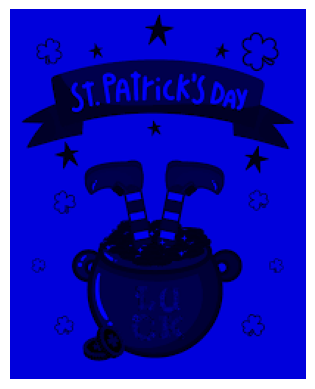

In [7]:
Ibonly = np.stack((Iz,Iz,Ib),axis =2)
plt.imshow(Ibonly)
plt.axis('off')

Text(0.5, 1.0, 'Histogram')

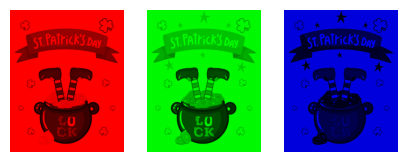

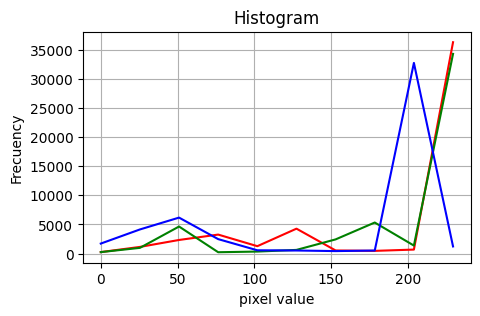

In [8]:
plt.figure(figsize=(5,10))
plt.subplot(1,3,1)
plt.imshow(Ironly)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(Igonly)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(Ibonly)
plt.axis('off')

h_r, bins_edges = np.histogram(Ir.flatten(),bins=10,range=(0,255))
h_g, bins_edges = np.histogram(Ig.flatten(),bins=10,range=(0,255))
h_b, bins_edges = np.histogram(Ib.flatten(),bins=10,range=(0,255))
plt.figure(figsize=(5,3))
plt.plot(bins_edges[:-1],h_r,color='red')
plt.plot(bins_edges[:-1],h_g,color='green')
plt.plot(bins_edges[:-1],h_b,color='blue')
plt.xlabel('pixel value')
plt.ylabel('Frecuency')
plt.grid()
plt.title('Histogram')

(-0.5, 200.5, 250.5, -0.5)

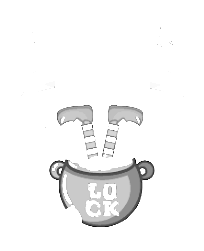

In [9]:
plt.figure(figsize=(5,3))
plt.imshow(Ir,cmap='gray',vmin=0,vmax=100)
plt.axis('off')

In [10]:
A=cv2.imread("data/Imagen.png")
Ab = A[:, :, 0]
Ag = A[:, :, 1]
Ar = A[:, :, 2]
Argb = np.stack((Ar, Ag, Ab), axis=2)
vmin = 50
vmax = 100
def saturaEscala(Argb, vmin, vmax):
    if Argb.min() < vmin or Argb.max() > vmax:
        Argb = np.clip(Argb, vmin, vmax)
    return Argb
np.unique(saturaEscala(Argb, vmin, vmax)[:, :, 2])

array([ 50,  51,  52,  53,  54,  55,  56,  59,  60,  61,  64,  65,  66,
        67,  70,  71,  72,  73,  76,  77,  78,  79,  82,  85,  86,  87,
        89,  90,  92,  93,  95,  96,  97, 100], dtype=uint8)

### Funcion histograma por canal
* Funcion histograma(A,nbins)
* devuelve rangos por canal y vector de frecuencias por canal

In [11]:
def HistogramaPorCanal(I = None, bins=10):
    ndim= np.ndim(I)
    if ndim == 2:
        h, bins_edges = np.histogram(I.flatten(), bins=bins, range=(0, 255))
        return h, bins_edges
    elif ndim == 3:
        _,_, nch = I.shape
        h_bin_edges_list = []
        for c in range(nch):
            h, bins_edges = np.histogram(I[:,:,c].flatten(), bins=bins, range=(0, 255))
            h_bin_edges_list.append((h, bins_edges))
        return h_bin_edges_list
    else:
        print('No está definida para este número de dimensiones')
        return None

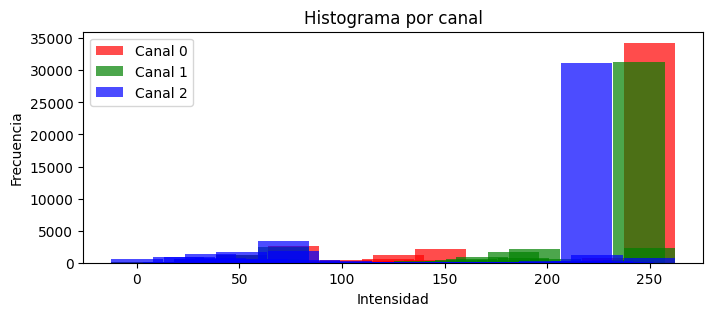

In [18]:
Img= Irgb.copy()
ndim= np.ndim(Img)
plt.figure(figsize=(8, 3))
if ndim==2:
    h_bins_edges = HistogramaPorCanal(Img, bins=50)
    plt.bar(h_bins_edges[:-1], h, width=25, color="red", alpha=0.7)
elif ndim==3:
    h_bin_edges_list = HistogramaPorCanal(Img, bins=50)
    colors = ['red', 'green', 'blue']
    for c,(h, bins_edges) in enumerate(h_bin_edges_list):
        plt.bar(bins_edges[:-1], h, width=25, color=colors[c], alpha=0.7, label=f'Canal {c}')
    plt.xlabel('Intensidad')
    plt.ylabel('Frecuencia')
    plt.title('Histograma por canal')
    plt.legend()

### CLipping

In [14]:
a = Img[100,50,2]
b = np.clip(a+100,0,255).astype('uint8')
b
b.dtype

dtype('uint8')

### Clip y quitar 50 de intensidad

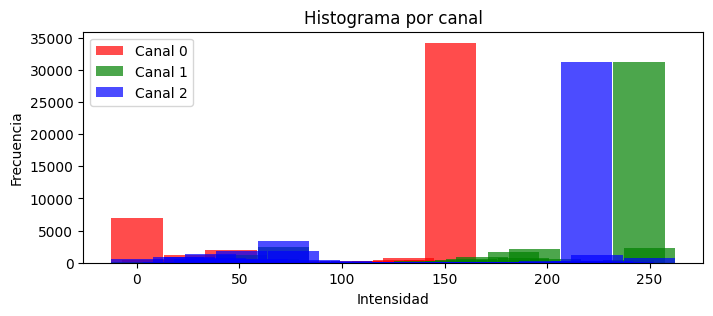

In [ ]:
I = Img.copy().astype(np.int16)
I[:, :, 0] = np.clip(I[:, :, 0] - 50, 0, 255)  # canal rojo
Inew = I.astype(np.uint8)
ndim= np.ndim(Inew)
plt.figure(figsize=(8, 3))
if ndim==2:
    h_bins_edges = HistogramaPorCanal(Inew, bins=50)
    plt.bar(h_bins_edges[:-1], h, width=25, color="red", alpha=0.7)
elif ndim==3:
    h_bin_edges_list = HistogramaPorCanal(Inew, bins=50)
    colors = ['red', 'green', 'blue']
    for c,(h, bins_edges) in enumerate(h_bin_edges_list):
        plt.bar(bins_edges[:-1], h, width=25, color=colors[c], alpha=0.7, label=f'Canal {c}')
    plt.xlabel('Intensidad')
    plt.ylabel('Frecuencia')
    plt.title('Histograma por canal')
    plt.legend()


### Gamma multiplication

In [ ]:
gamma = 0.8
Irgb3 = Irgb.copy()
Ir3 = Irgb3[:, :, 0]
Ir3 = np.clip(Ir3 * gamma, 0, 255).astype(np.uint8)
Irgb3[:, :, 0] = Ir3

Img = Irgb3.copy()
ndim = np.ndim(Img)
plt.figure(figsize=(8, 3))
if ndim == 2:
    h, bins_edges = HistogramaPorCanal(Img, bins=50)
    plt.bar(bins_edges[:-1], h, width=25, color='red', alpha=0.7)
elif ndim == 3:
    h_bins_edges_list = HistogramaPorCanal(Img, bins=50)
    colors = ['red', 'green', 'blue']
    for c, (h, bins_edges) in enumerate(h_bins_edges_list):
        plt.bar(bins_edges[:-1], h, width=25, color=colors[c], alpha=0.7, label=f'Canal {c}')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma')
plt.legend()